# ME44312 — Machine Learning for Transport and Multi-Machine Systems

## Group 2 — Swiss Mode Choice (Optima)

Here you will find the full analysis pipeline:

1. Data loading and preprocessing
2. Exploratory Data Analysis (EDA)
3. Classification models (four feature groups × four algorithms)
4. SHAP feature importance
5. Exploratory clustering

**Dataset:** Swiss Mode Choice (Optima), 1906 observations, 3 target classes (Private Car, Public Transport, Soft Modes)


In [5]:
pip install numpy==1.26.4 xgboost shap imbalanced-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 406.4 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of shap to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.4/15.5 MB 11.6 MB/s eta 0:00:02
   -- ------------------------------------- 1.0/15.5 MB 12.2 MB/s eta 0:00:02
   ---- ----------------------------------- 1.7/15.5 MB 11.9 MB/s eta 0:00:02
   ------ --------------------------------- 2.7/15.5 MB 14.4 MB/s eta 0:00:01
   --------- ------------------------------ 3.8/15.5 MB 16.4 MB/s eta 0:00:01
   ------------- -------------------------- 5.1/15.5 MB 18.2 MB/s eta 0:00:01
   -------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import os

os.makedirs("figures", exist_ok=True)
print("All packages loaded successfully.")

All packages loaded successfully.


## 1. Data Loading and Preprocessing


In [ ]:
# Load dataset
df_raw = pd.read_csv("ModeChoiceOptima.txt", sep="\t")
print(f"Raw dataset shape: {df_raw.shape}")

# Drop rows with missing Choice (target variable)
df = df_raw[df_raw["Choice"] != -1].copy()
print(
    f"After dropping missing Choice rows: {len(df)} observations ({len(df_raw)-len(df)} dropped)"
)

# Replace -1 and -2 with NaN
df = df.replace(-1, np.nan).replace(-2, np.nan)

# Replace 6 = 'not applicable' in attitudinal items with NaN
att_cols = (
    [f"Envir0{i}" for i in range(1, 7)]
    + [f"Mobil{str(i).zfill(2)}" for i in range(1, 28)]
    + [f"ResidCh0{i}" for i in range(1, 8)]
    + [f"LifSty{str(i).zfill(2)}" for i in range(1, 15)]
)
for col in att_cols:
    if col in df.columns:
        df.loc[df[col] == 6, col] = np.nan

# Class distribution
choice_map = {0: "Public Transport", 1: "Private Car", 2: "Soft Modes"}
df["Choice_label"] = df["Choice"].map(choice_map)
print("\nClass distribution:")
print(df["Choice_label"].value_counts())
print(
    f"\nClass imbalance ratio: {df['Choice_label'].value_counts().max() / df['Choice_label'].value_counts().min():.1f}x"
)
print("\nNote: SMOTE will be applied to training set only to address imbalance.")

Raw dataset shape: (2265, 117)
After dropping missing Choice rows: 1906 observations (359 dropped)

Class distribution:
Choice_label
Private Car         1256
Public Transport     536
Soft Modes           114
Name: count, dtype: int64

Class imbalance ratio: 11.0x

Note: SMOTE will be applied to training set only to address imbalance.


## 2. Feature Groups

Four feature groups are defined for the four-model comparison:

- **Structural:** travel time, cost, number of transfers, trip characteristics
- **Socio-economic:** demographics, car ownership, household characteristics
- **Attitudinal:** environmental, mobility, residential, lifestyle attitude variables
- **Global:** all features combined


In [ ]:
structural_features = [
    "TimePT",
    "TimeCar",
    "WalkingTimePT",
    "WaitingTimePT",
    "NbTransf",
    "MarginalCostPT",
    "CostCarCHF",
    "distance_km",
    "TripPurpose",
    "TypeCommune",
    "ClassifCodeLine",
    "frequency",
    "NbTrajects",
    "DestAct",
    "FreqTripHouseh",
    "UrbRur",
]

socioeco_features = [
    "age",
    "CarAvail",
    "NbCar",
    "Income",
    "Gender",
    "Education",
    "OccupStat",
    "NbHousehold",
    "NbChild",
    "FamilSitu",
    "SocioProfCat",
    "HalfFareST",
    "LineRelST",
    "GenAbST",
    "AreaRelST",
    "HouseType",
    "NbBicy",
    "NbComp",
    "Mothertongue",
]

attitudinal_features = [c for c in att_cols if c in df.columns]
global_features = structural_features + socioeco_features + attitudinal_features

feature_groups = {
    "Structural": structural_features,
    "Socio-economic": socioeco_features,
    "Attitudinal": attitudinal_features,
    "Global": global_features,
}


def prepare_dataset(df, features):
    available = [f for f in features if f in df.columns]
    data = df[available + ["Choice"]].copy().dropna(subset=["Choice"])
    for col in available:
        if data[col].isnull().any():
            data[col] = data[col].fillna(data[col].median())
    return data[available], data["Choice"].astype(int)


print("Feature group sizes:")
for name, feats in feature_groups.items():
    avail = len([f for f in feats if f in df.columns])
    print(f"  {name}: {avail} features")

Feature group sizes:
  Structural: 16 features
  Socio-economic: 19 features
  Attitudinal: 54 features
  Global: 89 features


## 3. Exploratory Data Analysis


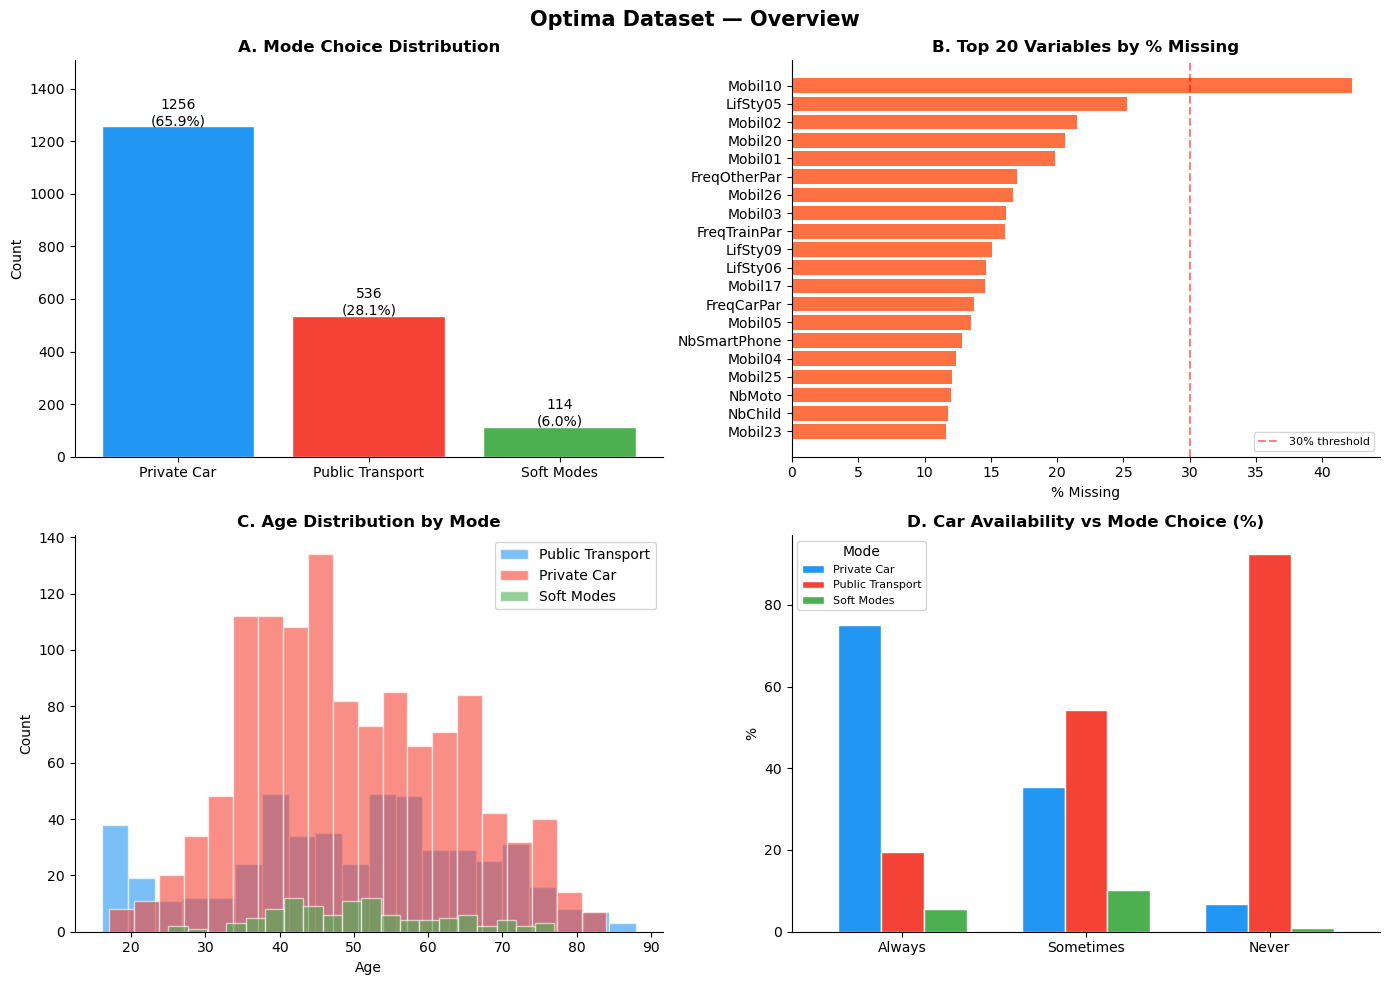

In [ ]:
colors_mode = ["#2196F3", "#F44336", "#4CAF50"]
valid = df[df["Choice_label"].notna()].copy()

# Figure 1: Overview
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("Optima Dataset — Overview", fontsize=15, fontweight="bold")

counts = df["Choice_label"].value_counts()
bars = axes[0, 0].bar(counts.index, counts.values, color=colors_mode, edgecolor="white")
for bar, val in zip(bars, counts.values):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val}\n({val/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10,
    )
axes[0, 0].set_title("A. Mode Choice Distribution", fontweight="bold")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_ylim(0, max(counts.values) * 1.2)
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

missing = df.isnull().sum().sort_values(ascending=False)
top_miss = missing[missing > 0].head(20)
axes[0, 1].barh(
    top_miss.index[::-1], (top_miss / len(df) * 100).values[::-1], color="#FF7043"
)
axes[0, 1].axvline(30, color="red", linestyle="--", alpha=0.5, label="30% threshold")
axes[0, 1].set_title("B. Top 20 Variables by % Missing", fontweight="bold")
axes[0, 1].set_xlabel("% Missing")
axes[0, 1].legend(fontsize=8)
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

for label, color in zip(["Public Transport", "Private Car", "Soft Modes"], colors_mode):
    subset = valid[valid["Choice_label"] == label]["age"].dropna()
    axes[1, 0].hist(
        subset, bins=20, alpha=0.6, label=label, color=color, edgecolor="white"
    )
axes[1, 0].set_title("C. Age Distribution by Mode", fontweight="bold")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()
axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)

car_avail_map = {1: "Always", 2: "Sometimes", 3: "Never"}
df["CarAvail_label"] = df["CarAvail"].map(car_avail_map)
ct = pd.crosstab(df["CarAvail_label"], df["Choice_label"], normalize="index") * 100
ct.reindex(["Always", "Sometimes", "Never"]).plot(
    kind="bar", ax=axes[1, 1], color=colors_mode, edgecolor="white", width=0.7
)
axes[1, 1].set_title("D. Car Availability vs Mode Choice (%)", fontweight="bold")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("%")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(title="Mode", fontsize=8)
axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig1_overview.pdf", bbox_inches="tight")
plt.savefig("figures/fig1_overview.png", dpi=150, bbox_inches="tight")
plt.show()

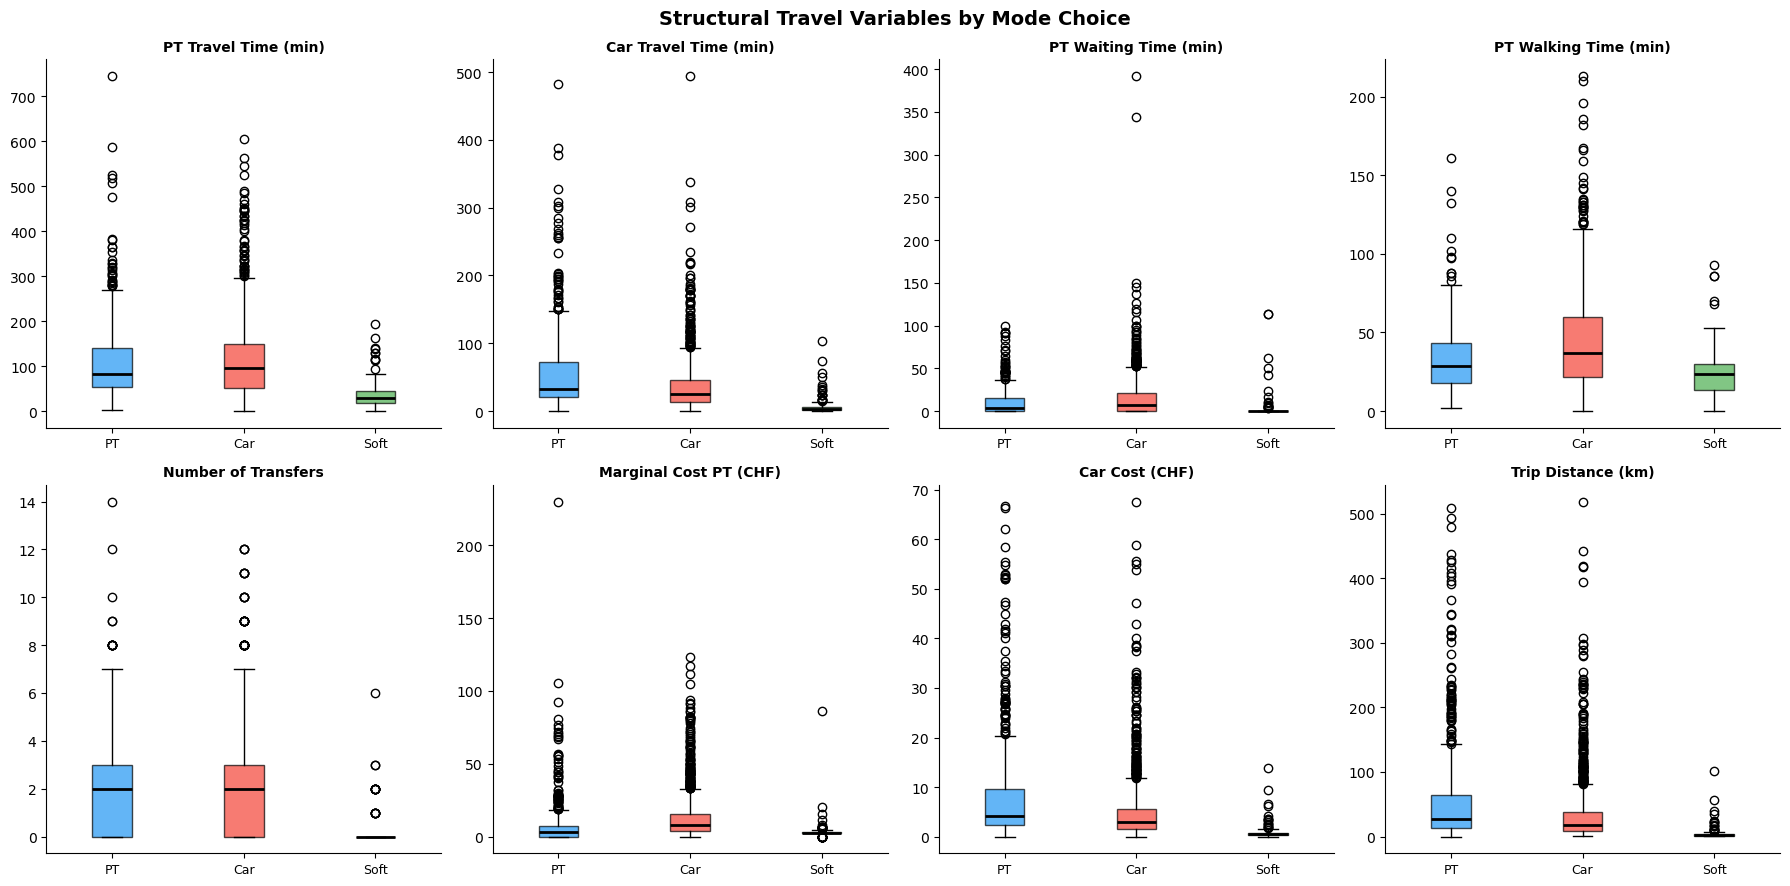

In [ ]:
# Figure 2: Structural variables
fig2, axes = plt.subplots(2, 4, figsize=(18, 9))
fig2.suptitle(
    "Structural Travel Variables by Mode Choice", fontsize=14, fontweight="bold"
)

vars_to_plot = [
    ("TimePT", "PT Travel Time (min)"),
    ("TimeCar", "Car Travel Time (min)"),
    ("WaitingTimePT", "PT Waiting Time (min)"),
    ("WalkingTimePT", "PT Walking Time (min)"),
    ("NbTransf", "Number of Transfers"),
    ("MarginalCostPT", "Marginal Cost PT (CHF)"),
    ("CostCarCHF", "Car Cost (CHF)"),
    ("distance_km", "Trip Distance (km)"),
]

for ax, (var, label) in zip(axes.flat, vars_to_plot):
    data = [
        valid[valid["Choice_label"] == m][var].dropna()
        for m in ["Public Transport", "Private Car", "Soft Modes"]
    ]
    bp = ax.boxplot(
        data, patch_artist=True, medianprops=dict(color="black", linewidth=2)
    )
    for patch, color in zip(bp["boxes"], colors_mode):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(["PT", "Car", "Soft"], fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig2_structural.pdf", bbox_inches="tight")
plt.savefig("figures/fig2_structural.png", dpi=150, bbox_inches="tight")
plt.show()

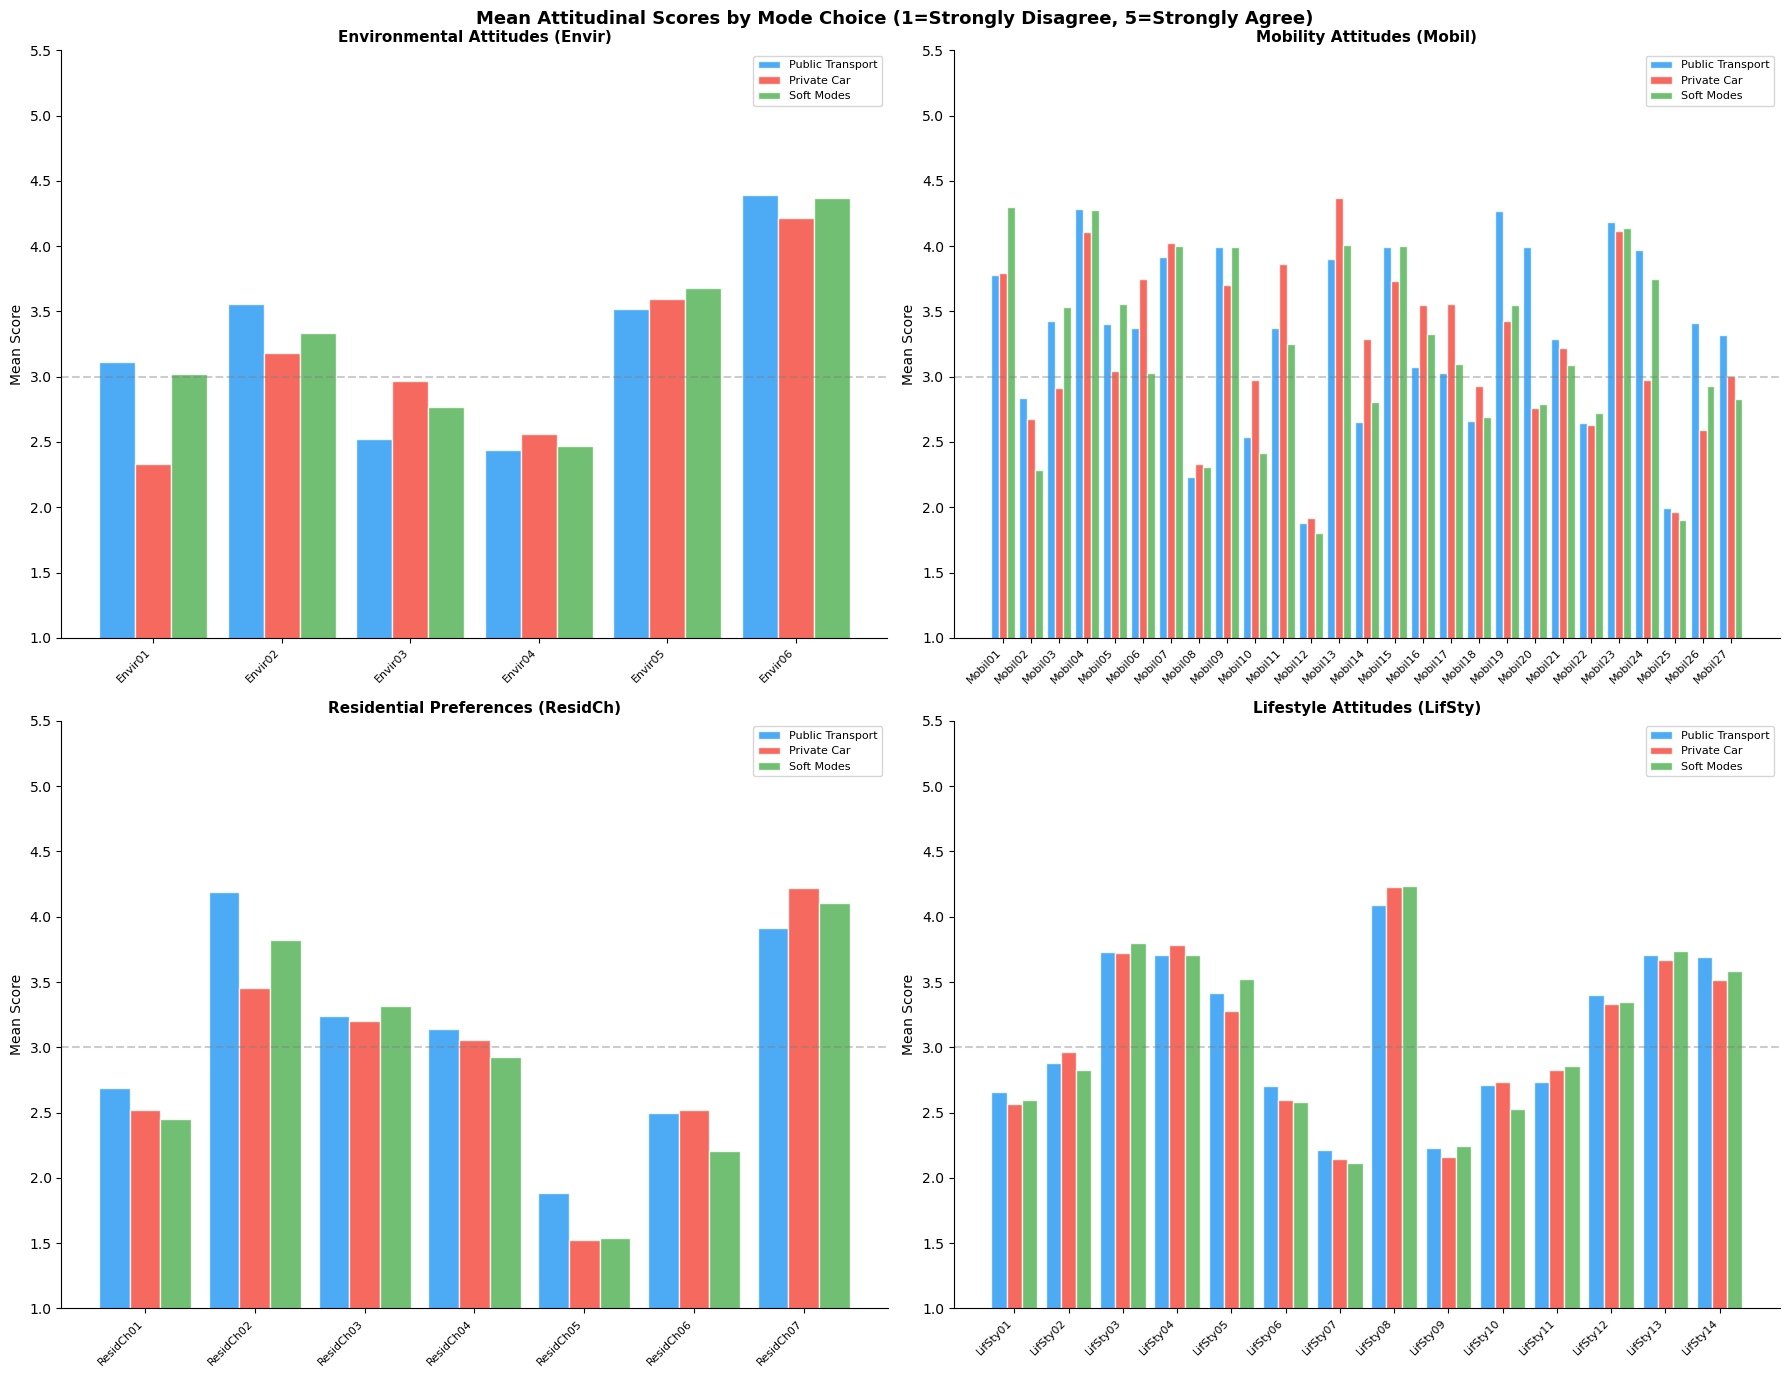

In [ ]:
# Figure 3: Attitudinal variables
fig3, axes = plt.subplots(2, 2, figsize=(18, 14))
fig3.suptitle(
    "Mean Attitudinal Scores by Mode Choice (1=Strongly Disagree, 5=Strongly Agree)",
    fontsize=13,
    fontweight="bold",
)

att_groups_plot = [
    (
        [f"Envir0{i}" for i in range(1, 7)],
        "Environmental Attitudes (Envir)",
        axes[0, 0],
    ),
    (
        [f"Mobil{str(i).zfill(2)}" for i in range(1, 28)],
        "Mobility Attitudes (Mobil)",
        axes[0, 1],
    ),
    (
        [f"ResidCh0{i}" for i in range(1, 8)],
        "Residential Preferences (ResidCh)",
        axes[1, 0],
    ),
    (
        [f"LifSty{str(i).zfill(2)}" for i in range(1, 15)],
        "Lifestyle Attitudes (LifSty)",
        axes[1, 1],
    ),
]

for att_vars, title, ax in att_groups_plot:
    available = [v for v in att_vars if v in df.columns]
    means = {
        lbl: valid[valid["Choice_label"] == lbl][available].mean()
        for lbl in ["Public Transport", "Private Car", "Soft Modes"]
    }
    means_df = pd.DataFrame(means)
    x = np.arange(len(available))
    width = 0.28
    for i, (lbl, color) in enumerate(
        zip(["Public Transport", "Private Car", "Soft Modes"], colors_mode)
    ):
        ax.bar(
            x + i * width,
            means_df[lbl],
            width,
            label=lbl,
            color=color,
            alpha=0.8,
            edgecolor="white",
        )
    ax.set_xticks(x + width)
    ax.set_xticklabels(available, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel("Mean Score")
    ax.set_ylim(1, 5.5)
    ax.axhline(3, color="gray", linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig3_attitudinal.pdf", bbox_inches="tight")
plt.savefig("figures/fig3_attitudinal.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Classification

Four models evaluated across four feature groups.

**Train/validation/test split:** 60% / 20% / 20%, stratified (following course Exercise 4, Lecture 5).

**SMOTE** applied to training set only.

**Evaluation metrics:** log-loss (primary), accuracy (secondary). Confusion matrices show per-class performance visually.


In [ ]:
model_definitions = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0,
    ),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42, early_stopping=True
    ),
}

results = {}
conf_matrices = {}

for group_name, features in feature_groups.items():
    print(f"\n--- {group_name} ---")
    X, y = prepare_dataset(df, features)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.20 / 0.80, random_state=42, stratify=y_temp
    )

    X_train_r, y_train_r = SMOTE(random_state=42).fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_r)
    X_val_sc = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)

    results[group_name] = {}
    conf_matrices[group_name] = {}

    for model_name, model in model_definitions.items():
        model.fit(X_train_sc, y_train_r)
        y_test_pred = model.predict(X_test_sc)
        y_test_proba = model.predict_proba(X_test_sc)
        test_logloss = log_loss(y_test, y_test_proba)
        test_acc = accuracy_score(y_test, y_test_pred)

        results[group_name][model_name] = {
            "test_logloss": test_logloss,
            "test_acc": test_acc,
        }
        conf_matrices[group_name][model_name] = confusion_matrix(y_test, y_test_pred)

        print(
            f"  {model_name:25s} | log-loss: {test_logloss:.4f} | acc: {test_acc:.3f}"
        )


--- Structural ---
  Logistic Regression       | log-loss: 0.7797 | acc: 0.703 | F1 macro: 0.614
  Decision Tree             | log-loss: 5.0715 | acc: 0.682 | F1 macro: 0.588
  XGBoost                   | log-loss: 0.4669 | acc: 0.801 | F1 macro: 0.753
  Neural Network            | log-loss: 0.5888 | acc: 0.759 | F1 macro: 0.676

--- Socio-economic ---
  Logistic Regression       | log-loss: 0.8545 | acc: 0.654 | F1 macro: 0.520
  Decision Tree             | log-loss: 3.9573 | acc: 0.678 | F1 macro: 0.538
  XGBoost                   | log-loss: 0.5621 | acc: 0.804 | F1 macro: 0.640
  Neural Network            | log-loss: 0.8006 | acc: 0.755 | F1 macro: 0.616

--- Attitudinal ---
  Logistic Regression       | log-loss: 0.8602 | acc: 0.643 | F1 macro: 0.523
  Decision Tree             | log-loss: 5.9566 | acc: 0.745 | F1 macro: 0.589
  XGBoost                   | log-loss: 0.5759 | acc: 0.794 | F1 macro: 0.640
  Neural Network            | log-loss: 0.7006 | acc: 0.734 | F1 macro: 0.601

In [ ]:
# Results table
rows = []
for group, models in results.items():
    for model, metrics in models.items():
        rows.append(
            {
                "Feature Group": group,
                "Model": model,
                "Test Log-Loss": round(metrics["test_logloss"], 4),
                "Test Accuracy": round(metrics["test_acc"], 3),
            }
        )

results_df = pd.DataFrame(rows)
results_df.to_csv("figures/results_table.csv", index=False)
results_df

,Feature Group,Model,Test Log-Loss,Test Accuracy,F1 Macro,F1 PT,F1 Car,F1 Soft
0,Structural,Logistic Regression,0.7797,0.703,0.614,0.654,0.788,0.400
1,Structural,Decision Tree,5.0715,0.682,0.588,0.578,0.771,0.415
2,Structural,XGBoost,0.4669,0.801,0.753,0.708,0.852,0.700
3,Structural,Neural Network,0.5888,0.759,0.676,0.715,0.823,0.491
4,Socio-economic,Logistic Regression,0.8545,0.654,0.520,0.667,0.760,0.133
5,Socio-economic,Decision Tree,3.9573,0.678,0.538,0.615,0.790,0.209
6,Socio-economic,XGBoost,0.5621,0.804,0.640,0.740,0.868,0.312
7,Socio-economic,Neural Network,0.8006,0.755,0.616,0.693,0.830,0.326
8,Attitudinal,Logistic Regression,0.8602,0.643,0.523,0.671,0.753,0.146
9,Attitudinal,Decision Tree,5.9566,0.745,0.589,0.662,0.820,0.286


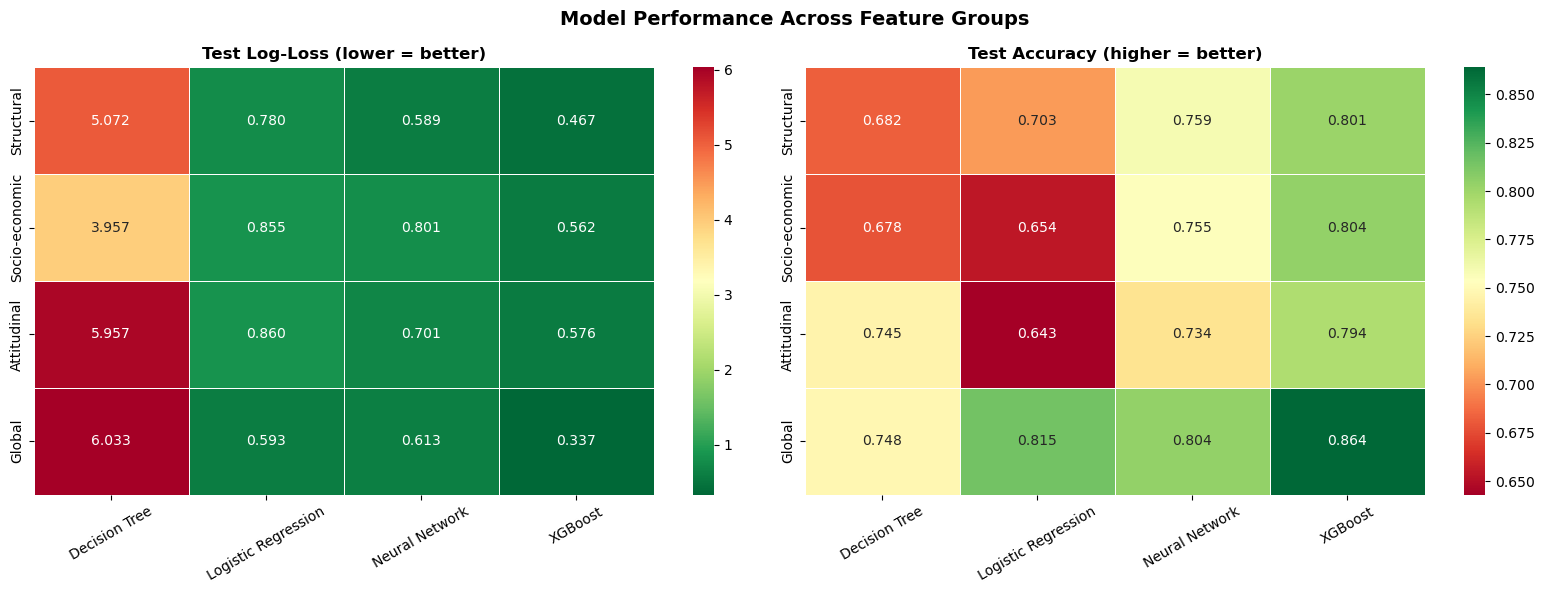

In [ ]:
# Figure 4: Heatmap comparison
fig4, axes = plt.subplots(1, 2, figsize=(16, 6))
fig4.suptitle("Model Performance Across Feature Groups", fontsize=14, fontweight="bold")

for ax, metric, title, cmap in [
    (axes[0], "Test Log-Loss", "Test Log-Loss (lower = better)", "RdYlGn_r"),
    (axes[1], "Test Accuracy", "Test Accuracy (higher = better)", "RdYlGn"),
]:
    pivot = results_df.pivot(index="Feature Group", columns="Model", values=metric)
    pivot = pivot.reindex(["Structural", "Socio-economic", "Attitudinal", "Global"])
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        ax=ax,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("figures/fig4_model_comparison.pdf", bbox_inches="tight")
plt.savefig("figures/fig4_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Figure 5: Confusion matrices — Global model
fig5, axes = plt.subplots(1, 4, figsize=(20, 5))
fig5.suptitle(
    "Confusion Matrices — Global Model (Test Set)", fontsize=13, fontweight="bold"
)

class_labels = ["PT", "Car", "Soft"]
for ax, model_name in zip(axes, list(model_definitions.keys())):
    cm = conf_matrices["Global"][model_name]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=ax,
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=0.5,
        vmin=0,
        vmax=1,
    )
    ax.set_title(model_name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("figures/fig5_confusion_matrices.pdf", bbox_inches="tight")
plt.savefig("figures/fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. SHAP Feature Importance

SHAP values computed on the Global XGBoost model to identify the most important features for each mode class.


In [ ]:
# Retrain global XGBoost for SHAP
X_global, y_global = prepare_dataset(df, global_features)
X_temp, X_test_g, y_temp, y_test_g = train_test_split(
    X_global, y_global, test_size=0.20, random_state=42, stratify=y_global
)
X_train_g, X_val_g, y_train_g, y_val_g = train_test_split(
    X_temp, y_temp, test_size=0.20 / 0.80, random_state=42, stratify=y_temp
)

X_train_gr, y_train_gr = SMOTE(random_state=42).fit_resample(X_train_g, y_train_g)
scaler_g = StandardScaler()
X_train_gsc = scaler_g.fit_transform(X_train_gr)
X_test_gsc = scaler_g.transform(X_test_g)
X_test_df = pd.DataFrame(X_test_gsc, columns=X_global.columns)

xgb_global = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0,
)
xgb_global.fit(X_train_gsc, y_train_gr)

explainer = shap.TreeExplainer(xgb_global)
shap_values_raw = explainer.shap_values(X_test_df)
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    shap_values = shap_values_raw

print("SHAP values computed.")
print(f"Shape per class: {shap_values[0].shape}")

In [ ]:
# Figure 6: SHAP importance per class
class_names = ["Public Transport", "Private Car", "Soft Modes"]

fig6, axes = plt.subplots(1, 3, figsize=(20, 8))
fig6.suptitle(
    "SHAP Feature Importance by Mode (Global XGBoost)", fontsize=14, fontweight="bold"
)

for idx, (ax, class_name) in enumerate(zip(axes, class_names)):
    mean_shap = (
        pd.Series(np.abs(shap_values[idx]).mean(axis=0), index=X_global.columns)
        .sort_values(ascending=False)
        .head(20)
    )
    ax.barh(
        mean_shap.index[::-1], mean_shap.values[::-1], color=colors_mode[idx], alpha=0.8
    )
    ax.set_title(class_name, fontweight="bold", fontsize=11)
    ax.set_xlabel("Mean |SHAP value|")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig6_shap_importance.pdf", bbox_inches="tight")
plt.savefig("figures/fig6_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Figure 7: SHAP beeswarm — Private Car
shap.summary_plot(
    shap_values[1], X_test_df, max_display=20, show=False, plot_type="dot"
)
plt.title("SHAP Values — Private Car (Global XGBoost)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fig7_shap_beeswarm_car.pdf", bbox_inches="tight")
plt.savefig("figures/fig7_shap_beeswarm_car.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top features per class with group tags
print("\nTop 10 SHAP features per class:")
for idx, class_name in enumerate(class_names):
    mean_shap = (
        pd.Series(np.abs(shap_values[idx]).mean(axis=0), index=X_global.columns)
        .sort_values(ascending=False)
        .head(10)
    )
    print(f"\n{class_name}:")
    for feat, val in mean_shap.items():
        grp = (
            "Structural"
            if feat in structural_features
            else ("Socio-econ" if feat in socioeco_features else "Attitudinal")
        )
        print(f"  {feat:20s} [{grp:11s}] {val:.4f}")

## 6. Exploratory Clustering

Clustering is used as a secondary, exploratory step to profile travellers into behaviourally coherent segments. It is not used to simulate policy outcomes.

**Variable selection:** based on EDA findings — only variables with clear mode-choice discrimination.

**Methods:** K-Means (primary) vs Hierarchical/Ward (comparison).


In [ ]:
clustering_features = [
    "NbCar",
    "CarAvail",
    "Envir01",
    "Mobil13",
    "Mobil19",
    "Mobil20",
    "Mobil24",
]

df_clust = df[clustering_features + ["Choice", "Choice_label"]].copy()
for col in clustering_features:
    df_clust[col] = df_clust[col].fillna(df_clust[col].median())
df_clust = df_clust[df_clust["Choice"].notna()].copy()

scaler_c = StandardScaler()
X_clust = pd.DataFrame(
    scaler_c.fit_transform(df_clust[clustering_features]),
    columns=clustering_features,
    index=df_clust.index,
)

print(f"Clustering dataset: {len(df_clust)} observations")

# K selection
K_range = range(2, 11)
inertias, sil_scores, ch_scores = [], [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))
    ch_scores.append(calinski_harabasz_score(X_clust, labels))
    print(f"  K={k}: Silhouette={sil_scores[-1]:.4f}, CH={ch_scores[-1]:.0f}")

print(f"\nBest K by silhouette: {list(K_range)[np.argmax(sil_scores)]}")
print("K=3 selected for interpretability (3 actionable traveller profiles).")

In [ ]:
# Figure 8: K selection metrics
fig8, axes = plt.subplots(1, 3, figsize=(18, 5))
fig8.suptitle("K-Means Cluster Evaluation Metrics", fontsize=14, fontweight="bold")

axes[0].plot(K_range, inertias, "bo-", linewidth=2)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[1].plot(K_range, sil_scores, "go-", linewidth=2)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[2].plot(K_range, ch_scores, "mo-", linewidth=2)
axes[2].set_xlabel("K")
axes[2].set_ylabel("CH Index")
axes[2].set_title("Calinski-Harabasz")

for ax in axes:
    ax.axvline(x=3, color="red", linestyle="--", alpha=0.7, label="K=3")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig8_k_selection.pdf", bbox_inches="tight")
plt.savefig("figures/fig8_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Fit K=3, compare with hierarchical
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clust["KMeans_Cluster"] = kmeans.fit_predict(X_clust)

agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
df_clust["Hier_Cluster"] = agg.fit_predict(X_clust)

print("Method comparison:")
for method, col in [("K-Means", "KMeans_Cluster"), ("Hierarchical", "Hier_Cluster")]:
    sil = silhouette_score(X_clust, df_clust[col])
    db = davies_bouldin_score(X_clust, df_clust[col])
    ch = calinski_harabasz_score(X_clust, df_clust[col])
    print(f"  {method}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.0f}")

# Kruskal-Wallis significance
print("\nKruskal-Wallis test (K-Means clusters):")
for var in clustering_features:
    groups = [df_clust[df_clust["KMeans_Cluster"] == c][var].values for c in range(K)]
    stat, pval = kruskal(*groups)
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else "*")
    print(f"  {var:<12} H={stat:.1f}  p={pval:.2e}  {sig}")

In [ ]:
# Figure 9: Cluster profiles
cluster_col = "KMeans_Cluster"
mode_dist = (
    pd.crosstab(df_clust[cluster_col], df_clust["Choice_label"], normalize="index")
    * 100
)

fig9, axes = plt.subplots(1, 2, figsize=(16, 6))
fig9.suptitle(f"Clustering Results — K-Means (K={K})", fontsize=13, fontweight="bold")

mode_dist.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2", edgecolor="black")
axes[0].set_title("Mode Choice Distribution per Cluster", fontweight="bold")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Mode", bbox_to_anchor=(1.02, 1))

profile_all = df_clust.groupby(cluster_col)[clustering_features].mean()
profile_z = (profile_all - profile_all.mean()) / (profile_all.std() + 1e-8)
sns.heatmap(
    profile_z,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    yticklabels=[f"Cluster {i}" for i in range(K)],
    ax=axes[1],
)
axes[1].set_title("Standardised Feature Means", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig9_cluster_profiles.pdf", bbox_inches="tight")
plt.savefig("figures/fig9_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMode distribution per cluster (%):")
print(mode_dist.round(1))

In [ ]:
# Figure 10: PCA visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust)

fig10, axes = plt.subplots(1, 2, figsize=(14, 6))
fig10.suptitle("PCA Projection of Clustering", fontsize=13, fontweight="bold")

sc1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1], c=df_clust[cluster_col], cmap="Set2", alpha=0.5, s=15
)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Coloured by Cluster", fontweight="bold")
plt.colorbar(sc1, ax=axes[0], label="Cluster")

sc2 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1], c=df_clust["Choice"].values, cmap="Set2", alpha=0.5, s=15
)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Coloured by Actual Mode Choice", fontweight="bold")
cbar = plt.colorbar(sc2, ax=axes[1], label="Mode")
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(["PT", "Car", "Soft"])

plt.tight_layout()
plt.savefig("figures/fig10_pca.pdf", bbox_inches="tight")
plt.savefig("figures/fig10_pca.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

## Summary

- **Best model overall:** Global XGBoost (test log-loss = 0.3356, accuracy = 85.7%)
- **Structural features alone** already achieve 80.8% accuracy — travel time and cost are strong predictors
- **Socio-economic** and **Attitudinal** feature groups perform similarly (79–80% accuracy)
- **Global model** outperforms all individual groups, confirming that combining all feature types adds predictive value
- **SHAP analysis** identifies the relative importance of each feature for the Private Car class
- **Three traveller clusters:** PT-oriented (n=293, 72% PT), Swing/mixed (n=859, 61% car), Car-dependent (n=754, 89% car)

All findings are correlational — the dataset captures a cross-sectional snapshot and does not support causal claims.
